# Lab 8. Video Processing for a motion classificaiton.

In [ ]:
import os
import tqdm
import random
import pathlib
import itertools
import collections

import cv2
import einops
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers
import shutil

from IPython.display import clear_output

In [ ]:
import torchvision.transforms.functional as F

Our guide will be based on the tensorflow guideline, but with a bit shorter steps structure due to different dataset arrangement.

`format_frames` is responsible for resizing processed frames from video files being the part of another function for splitting video files.

In [ ]:
def format_frames(frame, output_size):
  """
    Pad and resize an image from a video.

    Args:
      frame: Image that needs to resized and padded.
      output_size: Pixel size of the output frame image.

    Return:
      Formatted frame with padding of specified output size.
  """
  frame = tf.image.convert_image_dtype(frame, tf.float32)
  frame = tf.image.resize_with_pad(frame, *output_size)
  return frame

The `frames_from_video_file` function:
 - splits the videos into frames
 - reads a randomly chosen span of n_frames out of a video file
 - and returns them as a NumPy array

 To reduce memory and computation overhead, choose a small number of frames. In addition, pick the same number of frames from each video, which makes it easier to work on batches of data.

In [ ]:
def frames_from_video_file(video_path, n_frames, output_size = (224,224), frame_step = 15):
  """
    Creates frames from each video file present for each category.

    Args:
      video_path: File path to the video.
      n_frames: Number of frames extracted per video file.
      output_size: Pixel size of the output frame image.

    Return:
      An NumPy array of frames in the shape of (n_frames, height, width, channels).
  """
  # Read each video frame by frame
  result = []
  src = cv2.VideoCapture(str(video_path))

  video_length = int(src.get(cv2.CAP_PROP_FRAME_COUNT))

  need_length = 1 + (n_frames - 1) * frame_step

  if need_length > video_length:
    start = 0
  else:
    max_start = video_length - need_length
    start = random.randint(0, max_start + 1)

  # CAP_PROP_POS_FRAMES refers to the current frame position which we set to our variable frame_id (start)
  src.set(cv2.CAP_PROP_POS_FRAMES, start)
  # ret is a boolean indicating whether read was successful, frame is the image itself
  # check video

  ret, frame = src.read()
  result.append(format_frames(frame, output_size))

  for _ in range(n_frames - 1):
    for _ in range(frame_step):
      ret, frame = src.read()
    if ret:
      frame = format_frames(frame, output_size)
      result.append(frame)
    else:
      result.append(np.zeros_like(result[0]))
  src.release()
  result = np.array(result)[..., [2, 1, 0]]

  return result

Let's create **FrameGenerator** class in order to create an iterable object that can feed data into the TensorFlow data pipeline. The generator (`__call__`) function yields the frame array produced by frames_from_video_file and a one-hot encoded vector of the label associated with the set of frames.

You might notice that we are using `yield` as our outcome.

In [ ]:
class FrameGenerator:
    def __init__(self, path, n_frames, training = False):
        self.path = path
        self.n_frames = n_frames
        self.training = training
        self.class_names = sorted(set(p.name for p in self.path.iterdir() if p.is_dir()))
        self.class_ids_for_name = dict((name, idx) for idx, name in enumerate(self.class_names))

    def get_files_and_class_names(self):
        video_paths = list(self.path.glob('*/*.avi'))
        classes = [p.parent.name for p in video_paths]
        return video_paths, classes

    def __call__(self):
        video_paths, classes = self.get_files_and_class_names()

        pairs = list(zip(video_paths, classes))

        if self.training:
            random.shuffle(pairs)

        for path, name in pairs:
            video_frames = frames_from_video_file(path, self.n_frames)
            label = self.class_ids_for_name[name] # Encode labels
            yield video_frames, label

Creating subfolders...

In [ ]:
os.mkdir("test")
os.mkdir("train")
os.mkdir("val")

FileExistsError: [Errno 17] File exists: 'test'

Downloading our dataset...

In [ ]:
!gdown 1T_QJl2HRwHxoSNce2LiiTW7R4jsdIWkq

Downloading...
From (original): https://drive.google.com/uc?id=1T_QJl2HRwHxoSNce2LiiTW7R4jsdIWkq
From (redirected): https://drive.google.com/uc?id=1T_QJl2HRwHxoSNce2LiiTW7R4jsdIWkq&confirm=t&uuid=fcb01d41-56a7-4828-a367-dac47b8264bc
To: /content/UCF-101.zip
100% 6.96G/6.96G [01:14<00:00, 93.3MB/s]


In [ ]:
!unzip UCF-101.zip
# !unzip UCF101TrainTestSplits-RecognitionTask.zip
clear_output()

In [ ]:
# !rm -r UCF-101/.DS_Store
# !rm -r train/.DS_Store
# !rm -r test/.DS_Store
# !rm -r val/.DS_Store

Let's start preparing our dataset...

In [ ]:
num_class = 5


path_input = pathlib.Path( "UCF-101-final")
path_output_train = "train/"
path_output_test = "test/"
path_output_val = "val/"



i=1;
for file in path_input.iterdir():
    if i>num_class : break
    i=i+1
    os.mkdir(path_output_train+file.name)
    os.mkdir(path_output_val+file.name)
    os.mkdir(path_output_test+file.name)

    j=1;
    for f in file.iterdir():
        if(j<=30):
            shutil.copy( f, path_output_train+file.name)
        if(j>30 and j<=40):
            shutil.copy( f, path_output_val+file.name)
        if(j>40):
            shutil.copy( f, path_output_test+file.name)
        j=j+1
        if(j>50): break

FileExistsError: [Errno 17] File exists: 'train/Kayaking'

Applying defined `FrameGenerator` using predefined method `from_generator` and separating it into batches.

In [ ]:
n_frames = 10
batch_size = 8

output_signature = (tf.TensorSpec(shape = (None, None, None, 3), dtype = tf.float32),
                    tf.TensorSpec(shape = (), dtype = tf.int16))

train_ds = tf.data.Dataset.from_generator(FrameGenerator(pathlib.Path("train/"), n_frames, training=True),
                                          output_signature = output_signature)
# Batch the data
train_ds = train_ds.batch(batch_size)



val_ds = tf.data.Dataset.from_generator(FrameGenerator(pathlib.Path("val/"), n_frames),
                                        output_signature = output_signature)
val_ds = val_ds.batch(batch_size)



test_ds = tf.data.Dataset.from_generator(FrameGenerator(pathlib.Path("test/"), n_frames),
                                         output_signature = output_signature)

test_ds = test_ds.batch(batch_size)

Define size of video frame for our model.

In [ ]:
HEIGHT = 224
WIDTH = 224

On this stage we start conceptualizing our model. In this case we can create our mini-ResNet. Basically our model consists of three main parts:

* Convolution block
* Residual block
* Project block

Let's start with a convolution block. Given the context of processing video files, instead of 2-d images `(height, width)` we should operate with a video volume `(time, height, width)`. The most obvious approach to this problem would be replace each 2D convolution (Conv2D) with a 3D convolution (Conv3D).

Considering ResNet context, our model should be based on a `(2 + 1)D` convolution with **residual connections**. The `(2 + 1)D` convolution allows  the decomposition of the spatial and temporal dimensions, therefore creating two separate steps. An advantage of this approach is that factorizing the convolutions into spatial and temporal dimensions saves parameters.

For each output location a 3D convolution combines all the vectors from a 3D patch of the volume to create one vector in the output volume.

![](https://www.tensorflow.org/images/tutorials/video/3DCNN.png)

![](https://i.imgur.com/TYMETaw.gif)

This operation is takes `time * height * width * channels` inputs and produces `channels` outputs (assuming the number of input and output channels are the same. So a 3D convolution layer with a kernel size of `(3 x 3 x 3)` would need a weight-matrix with `27 * channels ** 2` entries, which is not that effective.

Instead of a single 3D convolution to process the time and space dimensions, it is proposed a `(2+1)D` convolution which processes the space and time dimensions separately. The figure below shows the factored spatial and temporal convolutions of a (2 + 1)D convolution.

![](https://www.tensorflow.org/images/tutorials/video/2plus1CNN.png)

As a result:

* By first operation we are trying to extrcat features from a frame using a 'classical' convolution

* By second operation we extract spatiotemporal interatcion between frames using temporal convolution

Operation would look like:

Input → Conv2D (1×3×3, stride 1) → BatchNorm → ReLU → Conv1D (3×1×1, stride 1) → BatchNorm → ReLU

In [ ]:
class Conv2Plus1D(keras.layers.Layer):
  def __init__(self, filters, kernel_size, padding, **kwargs):
    """
      A sequence of convolutional layers that first apply the convolution operation over the
      spatial dimensions, and then the temporal dimension.
    """
    super(Conv2Plus1D, self).__init__(**kwargs)
    self.seq = keras.Sequential([
        # Spatial decomposition
        layers.Conv3D(filters=filters,
                      kernel_size=(1, kernel_size[1], kernel_size[2]),
                      padding=padding),
        # Temporal decomposition
        layers.Conv3D(filters=filters,
                      kernel_size=(kernel_size[0], 1, 1),
                      padding=padding)
        ])

  def call(self, x):
    return self.seq(x)

  def get_config(self):
    config = super(Conv2Plus1D, self).get_config()
    config.update({
        "filters": self.seq.layers[0].filters,
        "kernel_size": (
            self.seq.layers[1].kernel_size[0],
            self.seq.layers[0].kernel_size[1],
            self.seq.layers[0].kernel_size[2]
        ),
        "padding": self.seq.layers[0].padding,
    })
    return config

Next part is **residual block**. A ResNet model is made from a sequence of residual blocks. A residual block has **two branches**.
* The main branch performs the calculation, but is difficult for gradients to flow through.

* The residual branch bypasses the main calculation and mostly just adds the input to the output of the main branch. Gradients flow easily through this branch. Therefore, an easy path from the loss function to any of the residual block's main branch will be present. This avoids the **vanishing gradient problem**.

SO let's create the main branch of the residual block with the following class. In contrast to the standard ResNet structure this uses the custom Conv2Plus1D layer instead of `layers.Conv2D`.

In [ ]:
class ResidualMain(keras.layers.Layer):
  """
    Residual block of the model with convolution, layer normalization, and the
    activation function, ReLU.
  """
  def __init__(self, filters, kernel_size, **kwargs):
    super(ResidualMain, self).__init__(**kwargs)
    self.seq = keras.Sequential([
        Conv2Plus1D(filters=filters,
                    kernel_size=kernel_size,
                    padding='same'),
        layers.LayerNormalization(),
        layers.ReLU(),
        Conv2Plus1D(filters=filters,
                    kernel_size=kernel_size,
                    padding='same'),
        layers.LayerNormalization()
    ])

  def call(self, x):
    return self.seq(x)

  def get_config(self):
    """
    Returns the config of the layer for serialization.
    """
    config = super(ResidualMain, self).get_config()
    config.update({
        "filters": self.seq.layers[0].seq.layers[0].filters,
        "kernel_size": self.seq.layers[0].seq.layers[0].kernel_size,
    })
    return config

In our case in order to make residual block applicable we need to align dimensions.

The **Project** layer below deals with cases where the number of channels is changed on the branch. In particular, a sequence of densely-connected layer followed by normalization is added.

In [ ]:
class Project(keras.layers.Layer):
  """
    Project certain dimensions of the tensor as the data is passed through different
    sized filters and downsampled.
  """
  def __init__(self, units, **kwargs):
    super(Project, self).__init__(**kwargs)
    self.seq = keras.Sequential([
        layers.Dense(units),
        layers.LayerNormalization()
    ])

  def call(self, x):
    return self.seq(x)

  def get_config(self):
    """
    Returns the config of the layer for serialization.
    """
    config = super(Project, self).get_config()
    config.update({
        "units": self.seq.layers[0].units,
    })
    return config

`add_residual_block` helps us to apply a skip connection between the layers of the model.

In [ ]:
def add_residual_block(input, filters, kernel_size):
  """
    Add residual blocks to the model. If the last dimensions of the input data
    and filter size does not match, project it such that last dimension matches.
  """
  out = ResidualMain(filters,
                     kernel_size)(input)

  res = input
  # Using the Keras functional APIs, project the last dimension of the tensor to
  # match the new filter size
  if out.shape[-1] != input.shape[-1]:
    res = Project(out.shape[-1])(res)

  return layers.add([res, out])

Last part is about **resizing** our (downsampling) our data. It allows for the model to examine specific parts of frames to detect patterns that may be specific to a certain action. Through downsampling, non-essential information can be discarded as well as speeding up processing through the model.

You might also notice applying **einops** library, which helps to make video transformations more convenient. More details:

https://einops.rocks/api/rearrange/

In [ ]:
class ResizeVideo(keras.layers.Layer):

  def __init__(self, height, width, **kwargs):
    """
    Custom layer to resize video frames using einops and the Resizing layer.
    """
    super(ResizeVideo, self).__init__(**kwargs)
    self.height = height
    self.width = width
    self.resizing_layer = layers.Resizing(self.height, self.width)

  def call(self, video):
    """
      Use the einops library to resize the tensor.

      Args:
        video: Tensor representation of the video, in the form of a set of frames.

      Return:
        A downsampled size of the video according to the new height and width it should be resized to.
    """
    # b stands for batch size, t stands for time, h stands for height,
    # w stands for width, and c stands for the number of channels.
    old_shape = einops.parse_shape(video, 'b t h w c')
    images = einops.rearrange(video, 'b t h w c -> (b t) h w c')
    images = self.resizing_layer(images)
    videos = einops.rearrange(
        images, '(b t) h w c -> b t h w c',
        t = old_shape['t'])
    return videos

    def get_config(self):
      """
      Returns the config of the layer for serialization.
      """
      config = super(ResizeVideo, self).get_config()
      config.update({
          "height": self.height,
          "width": self.width,
      })
    return config

In our case we don't need to use too many layers.

In [ ]:
def Model3D(height, width, num_frame, channel, num_classes):
    input_shape = (None, num_frame, height, width, channel)
    input = layers.Input(shape=(input_shape[1:]))
    x = input

    x = Conv2Plus1D(filters=16, kernel_size=(3, 7, 7), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = ResizeVideo(height // 2, width // 2)(x)

    # Block 1
    x = add_residual_block(x, 16, (3, 3, 3))
    x = ResizeVideo(height // 4, width // 4)(x)

    # Block 2
    x = add_residual_block(x, 32, (3, 3, 3))
    x = ResizeVideo(height // 8, width // 8)(x)

    # # Block 3
    # x = add_residual_block(x, 64, (3, 3, 3))
    # x = ResizeVideo(height // 16, width // 16)(x)

    # # Block 4
    # x = add_residual_block(x, 128, (3, 3, 3))

    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(num_classes, dtype='float32')(x)
    return keras.Model(input, x)

In [ ]:
# train_ds

In [ ]:
model = Model3D(HEIGHT, WIDTH, n_frames, 3, 5)
frames, label = next(iter(train_ds))
model.build(frames)

Let's take a look on our model...

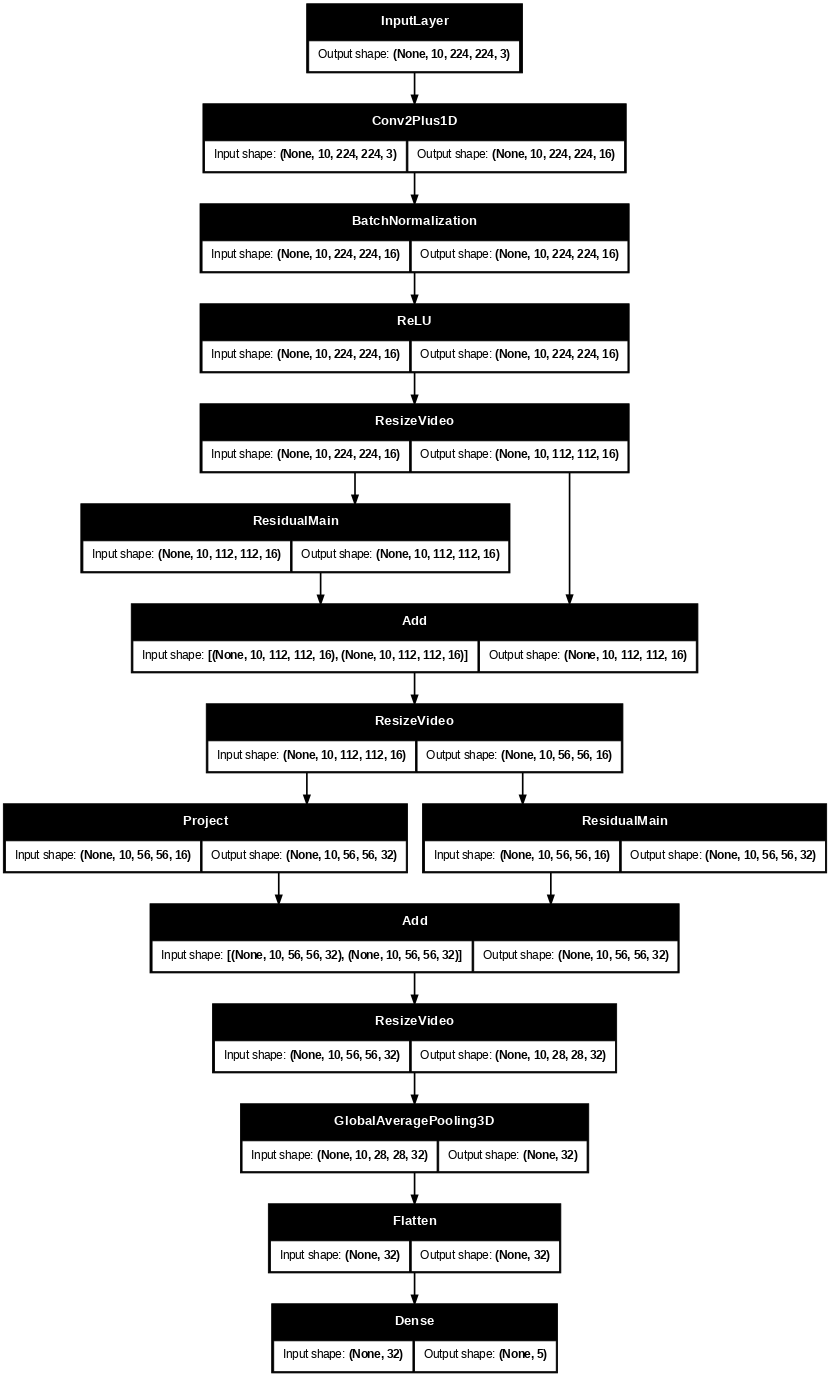

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, expand_nested=True, dpi=60, show_shapes=True)

In [ ]:
model.compile(loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0001),
              metrics = ['accuracy'])

In [ ]:
# history = model.fit(x = train_ds,epochs = 50, validation_data = val_ds)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "resnet_model_epoch5.h5",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True)

history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[checkpoint])

Epoch 1/20
     19/Unknown 306s 16s/step - accuracy: 0.2377 - loss: 1.5848

19/19 ━━━━━━━━━━━━━━━━━━━━ 349s 18s/step - accuracy: 0.2333 - loss: 1.5706 - val_accuracy: 0.2000 - val_loss: 1.7745
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.4157 - loss: 1.4672 

19/19 ━━━━━━━━━━━━━━━━━━━━ 348s 18s/step - accuracy: 0.3467 - loss: 1.4812 - val_accuracy: 0.2600 - val_loss: 1.6629
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.4339 - loss: 1.4474 

19/19 ━━━━━━━━━━━━━━━━━━━━ 353s 19s/step - accuracy: 0.4067 - loss: 1.4375 - val_accuracy: 0.3800 - val_loss: 1.4799
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 353s 19s/step - accuracy: 0.4600 - loss: 1.4139 - val_accuracy: 0.3400 - val_loss: 1.5455
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 382s 20s/step - accuracy: 0.4267 - loss: 1.3456 - val_accuracy: 0.3400 - val_loss: 1.4692
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.5436 - loss: 1.2826 

19/19 ━━━━━━━━━━━━━━━━━━━━ 382s 20s/step - accuracy: 0.4733 - loss: 1.3200 - val_accuracy: 0.4800 - val_loss: 1.3729
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 344s 18s/step - accuracy: 0.5200 - loss: 1.2558 - val_accuracy: 0.3600 - val_loss: 1.4174
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 343s 18s/step - accuracy: 0.5000 - loss: 1.2438 - val_accuracy: 0.4400 - val_loss: 1.3512
Epoch 9/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 386s 18s/step - accuracy: 0.4800 - loss: 1.2246 - val_accuracy: 0.4000 - val_loss: 1.3503
Epoch 10/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 395s 18s/step - accuracy: 0.4667 - loss: 1.2244 - val_accuracy: 0.3600 - val_loss: 1.3767
Epoch 11/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 340s 18s/step - accuracy: 0.5333 - loss: 1.1940 - val_accuracy: 0.4400 - val_loss: 1.3251
Epoch 12/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 341s 18s/step - accuracy: 0.5133 - loss: 1.1866 - val_accuracy: 0.3400 - val_loss: 1.4010
Epoch 13/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 351s 19s/step - accuracy: 0.5200 - loss: 1.1752 - val_accuracy: 0.4600 - 

19/19 ━━━━━━━━━━━━━━━━━━━━ 342s 18s/step - accuracy: 0.6533 - loss: 1.0323 - val_accuracy: 0.5200 - val_loss: 1.1045
Epoch 19/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.5853 - loss: 1.0814 

19/19 ━━━━━━━━━━━━━━━━━━━━ 382s 20s/step - accuracy: 0.6133 - loss: 1.0619 - val_accuracy: 0.5400 - val_loss: 1.1257
Epoch 20/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.6266 - loss: 1.0184 

19/19 ━━━━━━━━━━━━━━━━━━━━ 340s 18s/step - accuracy: 0.6267 - loss: 1.0449 - val_accuracy: 0.5800 - val_loss: 1.0662


In [61]:
model.evaluate(test_ds, return_dict=True)

7/7 ━━━━━━━━━━━━━━━━━━━━ 52s 7s/step - accuracy: 0.4800 - loss: 1.1751


{'accuracy': 0.47999998927116394, 'loss': 1.175075888633728}

In [62]:
model.summary()

Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_27      │ (None, 10, 224,   │          0 │ -                 │
│ (InputLayer)        │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_plus1d_15     │ (None, 10, 224,   │      3,152 │ input_layer_27[0… │
│ (Conv2Plus1D)       │ 224, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 224,   │         64 │ conv2_plus1d_15[… │
│ (BatchNormalizatio… │ 224, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_9 (ReLU)      │ (None, 10, 224,   │          0 │ batch_normalizat… │
│                     │ 224, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resize_video_9      │ (None, 10, 112,   │          0 │ re_lu_9[0][0]     │
│ (ResizeVideo)       │ 112, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_main_6     │ (None, 10, 112,   │      6,272 │ resize_video_9[0… │
│ (ResidualMain)      │ 112, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 10, 112,   │          0 │ resize_video_9[0… │
│                     │ 112, 16)          │            │ residual_main_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resize_video_10     │ (None, 10, 56,    │          0 │ add_6[0][0]       │
│ (ResizeVideo)       │ 56, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ project_3 (Project) │ (None, 10, 56,    │        608 │ resize_video_10[… │
│                     │ 56, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_main_7     │ (None, 10, 56,    │     20,224 │ resize_video_10[… │
│ (ResidualMain)      │ 56, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 10, 56,    │          0 │ project_3[0][0],  │
│                     │ 56, 32)           │            │ residual_main_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resize_video_11     │ (None, 10, 28,    │          0 │ add_7[0][0]       │
│ (ResizeVideo)       │ 28, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ resize_video_11[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 32)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 5)         │        165 │ flatten_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 91,393 (357.01 KB)

 Trainable params: 30,453 (118.96 KB)

 Non-trainable params: 32 (128.00 B)

 Optimizer params: 60,908 (237.93 KB)

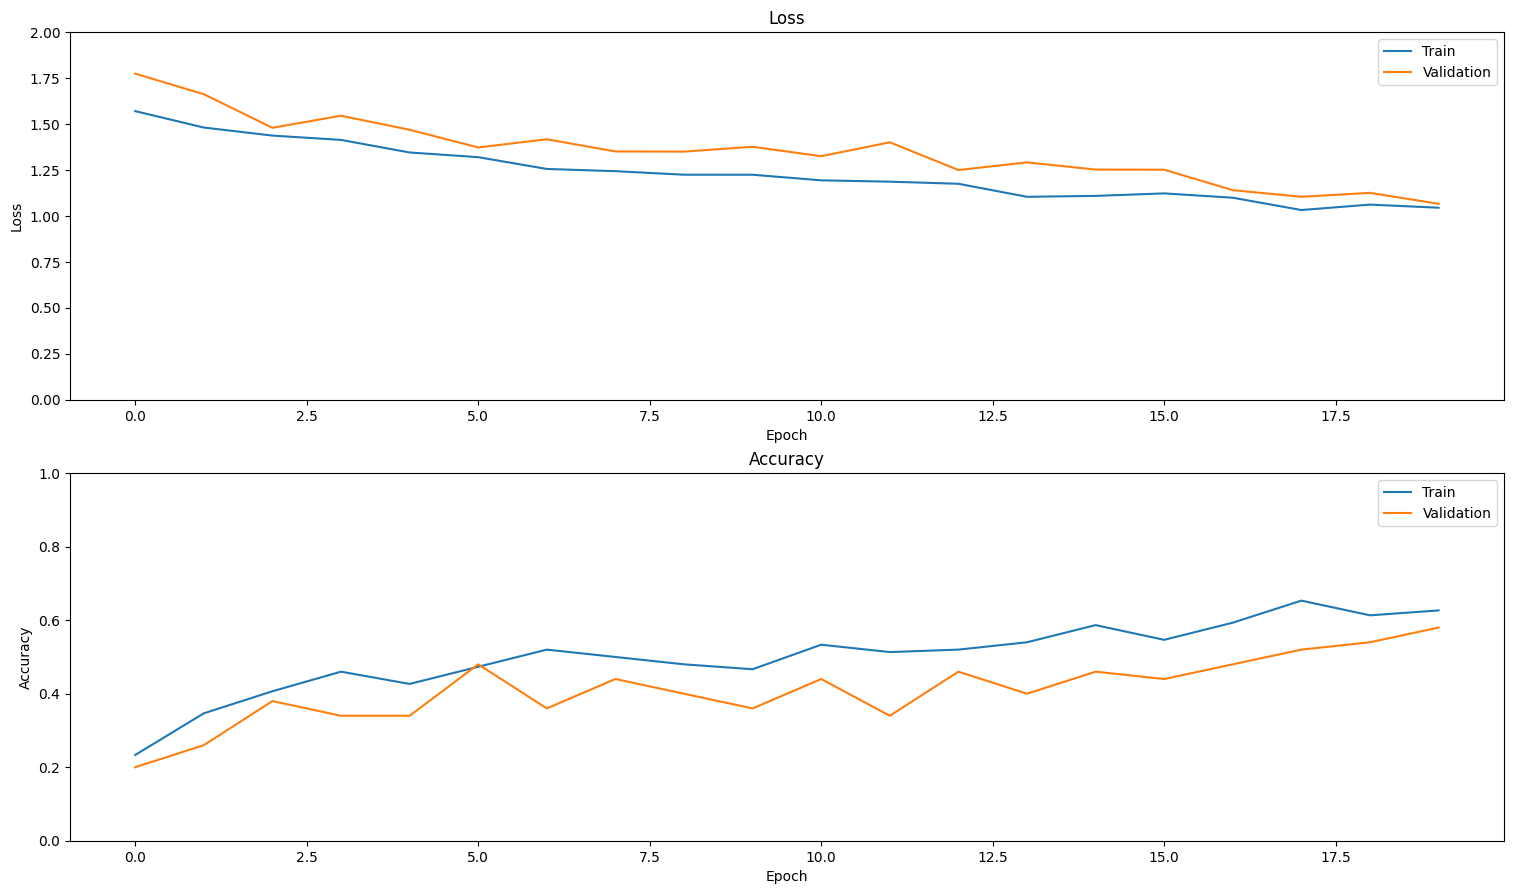

In [63]:
def plot_history(history):
  """
    Plotting training and validation learning curves.

    Args:
      history: model history with all the metric measures
  """
  fig, (ax1, ax2) = plt.subplots(2)

  fig.set_size_inches(18.5, 10.5)

  # Plot loss
  ax1.set_title('Loss')
  ax1.plot(history.history['loss'], label = 'train')
  ax1.plot(history.history['val_loss'], label = 'test')
  ax1.set_ylabel('Loss')

  # Determine upper bound of y-axis
  max_loss = max(history.history['loss'] + history.history['val_loss'])

  ax1.set_ylim([0, np.ceil(max_loss)])
  ax1.set_xlabel('Epoch')
  ax1.legend(['Train', 'Validation'])

  # Plot accuracy
  ax2.set_title('Accuracy')
  ax2.plot(history.history['accuracy'],  label = 'train')
  ax2.plot(history.history['val_accuracy'], label = 'test')
  ax2.set_ylabel('Accuracy')
  ax2.set_ylim([0, 1])
  ax2.set_xlabel('Epoch')
  ax2.legend(['Train', 'Validation'])

  plt.show()

plot_history(history)

We can upload a model trained on 20 epochs...

In [64]:
!gdown 1N06epZ7ed8VtqmxZ0uFlFSajhJSVTsh1
# !gdown 1HZqpaDAdpYUq89puNHdqbV7SBuuBngTp

Downloading...
From: https://drive.google.com/uc?id=1N06epZ7ed8VtqmxZ0uFlFSajhJSVTsh1
To: /content/resnet_model.h5
100% 486k/486k [00:00<00:00, 116MB/s]


DON'T forget to provide a serialization logic for custom layers. Otherwise,  preloaded weights for the model WILL NOT work.

More details about custom objects:

https://www.tensorflow.org/tutorials/keras/save_and_load#saving_custom_objects

In [65]:
from keras.models import load_model

loaded_model = load_model(
    'resnet_model.h5',
    custom_objects={
        'Conv2Plus1D': Conv2Plus1D,
        'ResizeVideo': ResizeVideo,
        'ResidualMain': ResidualMain,
        'Project': Project
    }
)

In [66]:
loaded_model.evaluate(test_ds, return_dict=True)

7/7 ━━━━━━━━━━━━━━━━━━━━ 44s 6s/step - accuracy: 0.1400 - loss: 2.4455


{'accuracy': 0.14000000059604645, 'loss': 2.445502519607544}

You can try to train yout own model for the whole UCF dataset, but remember that it takes a lot of time, probably might take several days, example can be found here, you can take a short look:

https://colab.research.google.com/drive/1Ab3Sf9mwRmVp5P6YaRCd-bQjdINikTwB?usp=sharing

Repository to reproduce initial ResNet model:

https://github.com/pytorch/vision/tree/main/references/video_classification

Surely, we have more advanced datasets for a motion detection. As one of the most advanced usually used as a benchmark is **Kinetics** dataset. There exists different versions for this dataset, which can contain 400, 600 or 700 classes.
Let's take a look on Kinetics-based models.

For example, I3D by DeepMind.

<!-- ![](https://didpurwanto.com/public/articles/i3d_framework.PNG) -->

![](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*Ab76Q3eRUOOuIX87hs-GZg.png)


In [ ]:
!pip install git+https://github.com/tensorflow/docs
clear_output()

In [ ]:
import ssl
import tempfile
import imageio
from urllib import request
import tensorflow_hub as hub
from tensorflow_docs.vis import embed
from IPython.display import Image, display

In [ ]:
frames = ... # Shape [batch_size, frame_count, height=224, width=224, 3]
i3d = hub.load("https://www.kaggle.com/models/deepmind/i3d-kinetics/TensorFlow1/400/1").signatures['default']

In [ ]:
# Get the kinetics-400 action labels from the GitHub repository.
KINETICS_URL = "https://raw.githubusercontent.com/deepmind/kinetics-i3d/master/data/label_map.txt"
with request.urlopen(KINETICS_URL) as obj:
  labels = [line.decode("utf-8").strip() for line in obj.readlines()]
print("Found %d labels." % len(labels))

In [ ]:
_CACHE_DIR = tempfile.mkdtemp()
UCF_ROOT = "https://www.crcv.ucf.edu/THUMOS14/UCF101/UCF101/"
unverified_context = ssl._create_unverified_context()

def fetch_ucf_video(video):
  """Fetchs a video and cache into local filesystem."""
  cache_path = os.path.join(_CACHE_DIR, video)
  if not os.path.exists(cache_path):
    urlpath = request.urljoin(UCF_ROOT, video)
    print("Fetching %s => %s" % (urlpath, cache_path))
    data = request.urlopen(urlpath, context=unverified_context).read()
    open(cache_path, "wb").write(data)
  return cache_path

def crop_center_square(frame):
  y, x = frame.shape[0:2]
  min_dim = min(y, x)
  start_x = (x // 2) - (min_dim // 2)
  start_y = (y // 2) - (min_dim // 2)
  return frame[start_y:start_y+min_dim,start_x:start_x+min_dim]

def load_video(path, max_frames=0, resize=(224, 224)):
  cap = cv2.VideoCapture(path)
  frames = []
  try:
    while True:
      ret, frame = cap.read()
      if not ret:
        break
      frame = crop_center_square(frame)
      frame = cv2.resize(frame, resize)
      frame = frame[:, :, [2, 1, 0]]
      frames.append(frame)

      if len(frames) == max_frames:
        break
  finally:
    cap.release()
  return np.array(frames) / 255.0

def to_gif(images):
  converted_images = np.clip(images * 255, 0, 255).astype(np.uint8)
  imageio.mimsave('./animation.gif', converted_images, fps=25)
  return embed.embed_file('./animation.gif')

In [ ]:
video_path = fetch_ucf_video("v_CricketShot_g04_c02.avi")
sample_video = load_video(video_path)

In [ ]:
def predict(sample_video):
  # Add a batch axis to the sample video.
  model_input = tf.constant(sample_video, dtype=tf.float32)[tf.newaxis, ...]

  logits = i3d(model_input)['default'][0]
  probabilities = tf.nn.softmax(logits)

  print("Top 5 actions:")
  for i in np.argsort(probabilities)[::-1][:5]:
    print(f"  {labels[i]:22}: {probabilities[i] * 100:5.2f}%")

In [ ]:
sample_video.shape

In [ ]:
to_gif(sample_video)

In [ ]:
predict(sample_video)

And, of course, it means that we can download any video from the Web and make a prediction.

In [ ]:
!curl -O https://upload.wikimedia.org/wikipedia/commons/8/86/End_of_a_jam.ogv

In [ ]:
!curl -O https://upload.wikimedia.org/wikipedia/commons/1/1b/Tony_Hawk_at_the_California_Hall_of_Fame_Induction_Event_-_2019.ogv

In [ ]:
sample_video = load_video("End_of_a_jam.ogv")[:200]
sample_video.shape

In [ ]:
to_gif(sample_video)

In [ ]:
predict(sample_video)

###**That's it for today.**

---------------------------------

# Hometask (2 points)

In this task you are asked to train a model on your choice. For example, you can go through [tf.keras.applications](https://www.tensorflow.org/api_docs/python/tf/keras/applications) and choose a model to train it on the UCF-101 dataset. Otherwise, you can do it on pytorch framework.

Requirements:

* Choose a model from the pretrained list
* Download a UCF-101 dataset and choose at least 10 classes for training and testing parts
* Freeze backbone layers and retrain only classifcation part
* Save a model correctly so you could be able to restore it
* Construct a training graph of the trained model
* Load saved weights and recalculate metrics to construct a confusion matrix

Good Luck!
